In [5]:
pip install boto3

Note: you may need to restart the kernel to use updated packages.


In [24]:
!pip install wordcloud

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import boto3
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from collections import Counter
from io import StringIO
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

In [9]:
# Load Data
df = pd.read_csv('sentimen_cyberbullying.csv')
df

,No,Sentimen
0,1,anjing poodle ku baru aja makan 3x sehari pada...
1,2,dasar goblok ngerjain tugas aja salah mulu men...
2,3,babi
3,4,harga daging babi di pasar naik lagi bikin bud...
4,5,mati aja lo sekalian ga ada yang butuh lo di d...
...,...,...
495,496,babi hutan menjadi salah satu hama pertanian p...
496,497,si tolol itu ga pernah mau ngaku salah padahal...
497,498,goblok banget lo tuh masuk rapat penting denga...
498,499,anjing


In [10]:
import boto3
import pandas as pd
from io import StringIO

s3 = boto3.client('s3', region_name='ap-southeast-1')

bucket = '24083010052-sentimencyberbullying-bucket'
key = 'processed/sentimen_clean.csv'

obj = s3.get_object(Bucket=bucket, Key=key)
data = obj['Body'].read().decode('utf-8')

df_processed = pd.read_csv(StringIO(data))

df_processed.head()

,No,Sentimen,Sentimen_clean,Label
0,1,anjing poodle ku baru aja makan 3x sehari pada...,anjing poodle ku baru aja makan 3x sehari pada...,non-cyberbully
1,2,dasar goblok ngerjain tugas aja salah mulu men...,dasar goblok ngerjain tugas aja salah mulu men...,cyberbully
2,4,harga daging babi di pasar naik lagi bikin bud...,harga daging babi di pasar naik lagi bikin bud...,non-cyberbully
3,5,mati aja lo sekalian ga ada yang butuh lo di d...,mati aja lo sekalian ga ada yang butuh lo di d...,cyberbully
4,6,orang itu kelakuannya tolol banget masa passwo...,orang itu kelakuannya tolol banget masa passwo...,cyberbully


In [11]:
# Cek null bawaan CSV
print("=== NULL VALUE ===")
print(df.isnull().sum())

# Tandai baris yang isinya cuma 1 kata (no context)
df['jumlah_kata'] = df['Sentimen'].astype(str).apply(lambda x: len(x.strip().split()))

print(f"\nData 1 kata (missing context) : {(df['jumlah_kata'] == 1).sum()}")
print(f"Data lebih dari 1 kata        : {(df['jumlah_kata'] > 1).sum()}")
df[df['jumlah_kata'] == 1]

=== NULL VALUE ===
No          0
Sentimen    0
dtype: int64

Data 1 kata (missing context) : 188
Data lebih dari 1 kata        : 312


,No,Sentimen,jumlah_kata
2,3,babi,1
6,7,goblok,1
10,11,anjing,1
13,14,tolol,1
16,17,mati,1
...,...,...,...
489,490,tolol,1
490,491,goblok,1
492,493,anjing,1
494,495,mati,1


In [12]:
def clean_text(text):
    text = str(text).lower()               # lowercase
    text = re.sub(r'[^\w\s]', '', text)    # hapus simbol & tanda baca
    text = re.sub(r'\s+', ' ', text)       # hapus spasi berlebih
    text = text.strip()
    return text

df['Sentimen_clean'] = df['Sentimen'].apply(clean_text)

print("Contoh hasil cleaning:")
df[['Sentimen', 'Sentimen_clean']]

Contoh hasil cleaning:


,Sentimen,Sentimen_clean
0,anjing poodle ku baru aja makan 3x sehari pada...,anjing poodle ku baru aja makan 3x sehari pada...
1,dasar goblok ngerjain tugas aja salah mulu men...,dasar goblok ngerjain tugas aja salah mulu men...
2,babi,babi
3,harga daging babi di pasar naik lagi bikin bud...,harga daging babi di pasar naik lagi bikin bud...
4,mati aja lo sekalian ga ada yang butuh lo di d...,mati aja lo sekalian ga ada yang butuh lo di d...
...,...,...
495,babi hutan menjadi salah satu hama pertanian p...,babi hutan menjadi salah satu hama pertanian p...
496,si tolol itu ga pernah mau ngaku salah padahal...,si tolol itu ga pernah mau ngaku salah padahal...
497,goblok banget lo tuh masuk rapat penting denga...,goblok banget lo tuh masuk rapat penting denga...
498,anjing,anjing


In [13]:
# Simpan dulu data 1 kata untuk catatan
df_missing = df[df['jumlah_kata'] == 1].copy()
print(f"Data 1 kata yang dihapus: {len(df_missing)}")

# Hapus data 1 kata
df_clean = df[df['jumlah_kata'] > 1].copy()

# Hapus duplikat
sebelum = len(df_clean)
df_clean = df_clean.drop_duplicates(subset='Sentimen_clean')
print(f"Duplikat dihapus: {sebelum - len(df_clean)}")
print(f"Jumlah data bersih: {len(df_clean)}")

Data 1 kata yang dihapus: 188
Duplikat dihapus: 0
Jumlah data bersih: 312


In [14]:
# Labelling

# Kata kunci yang dalam konteks cyberbullying
kata_kunci = ['anjing', 'babi', 'goblok', 'mati', 'tolol']

# Aturan labeling sederhana berbasis konteks
konteks_non_bully = [
    'pelihara', 'poodle', 'golden', 'retriever', 'labrador', 'herder',
    'chihuahua', 'vaksin', 'dokter hewan', 'daging', 'masak', 'guling',
    'ternak', 'peternak', 'kandang', 'hutan', 'liar', 'bali', 'adat',
    'film', 'cerita', 'pasar', 'harga', 'budget', 'konservasi',
    'penelitian', 'dokumenter', 'trainer', 'shelter', 'sterilisasi',
    'komunitas', 'mitologi', 'petani', 'kebun', 'sawah', 'pedalaman',
    'jantan', 'betina', 'anak', 'indukan', 'bobot', 'subsidi', 'lomba',
    'border', 'collie', 'dachshund', 'chow', 'greyhound', 'malamute',
    'melahirkan', 'ras', 'bulu', 'gonggong'
]

def label_sentimen(text):
    text_lower = str(text).lower()

    # Cek apakah mengandung kata kunci bully
    ada_kata_kunci = any(k in text_lower for k in kata_kunci)

    if not ada_kata_kunci:
        return 'non-cyberbully'

    # Kalau ada kata kunci, cek konteks
    ada_konteks_non = any(k in text_lower for k in konteks_non_bully)

    if ada_konteks_non:
        return 'non-cyberbully'
    else:
        return 'cyberbully'

df_clean['Label'] = df_clean['Sentimen_clean'].apply(label_sentimen)

print("=== DISTRIBUSI LABEL ===")
print(df_clean['Label'].value_counts())
print(f"\nPersentase cyberbully : {(df_clean['Label']=='cyberbully').mean()*100:.1f}%")
print(f"Persentase non-bully  : {(df_clean['Label']=='non-cyberbully').mean()*100:.1f}%")

=== DISTRIBUSI LABEL ===
Label
cyberbully        215
non-cyberbully     97
Name: count, dtype: int64

Persentase cyberbully : 68.9%
Persentase non-bully  : 31.1%


In [15]:
# Simpan hasil preprocessing

df_clean[['No', 'Sentimen', 'Sentimen_clean', 'Label']].to_csv(
    'sentimen_clean.csv',
    index=False
)

print("✅ File tersimpan: sentimen_clean.csv")
print(f"\nRingkasan akhir:")
print(f"  Data awal       : 500")
print(f"  Dihapus (1 kata): {len(df_missing)}")
print(f"  Data bersih     : {len(df_clean)}")
print()
df_clean[['No', 'Sentimen', 'Sentimen_clean', 'Label']]

✅ File tersimpan: sentimen_clean.csv

Ringkasan akhir:
  Data awal       : 500
  Dihapus (1 kata): 188
  Data bersih     : 312



,No,Sentimen,Sentimen_clean,Label
0,1,anjing poodle ku baru aja makan 3x sehari pada...,anjing poodle ku baru aja makan 3x sehari pada...,non-cyberbully
1,2,dasar goblok ngerjain tugas aja salah mulu men...,dasar goblok ngerjain tugas aja salah mulu men...,cyberbully
3,4,harga daging babi di pasar naik lagi bikin bud...,harga daging babi di pasar naik lagi bikin bud...,non-cyberbully
4,5,mati aja lo sekalian ga ada yang butuh lo di d...,mati aja lo sekalian ga ada yang butuh lo di d...,cyberbully
5,6,orang itu kelakuannya tolol banget masa passwo...,orang itu kelakuannya tolol banget masa passwo...,cyberbully
...,...,...,...,...
493,494,dasar anjing lo berani-beraninya nipu orang ya...,dasar anjing lo beraniberaninya nipu orang yan...,cyberbully
495,496,babi hutan menjadi salah satu hama pertanian p...,babi hutan menjadi salah satu hama pertanian p...,non-cyberbully
496,497,si tolol itu ga pernah mau ngaku salah padahal...,si tolol itu ga pernah mau ngaku salah padahal...,cyberbully
497,498,goblok banget lo tuh masuk rapat penting denga...,goblok banget lo tuh masuk rapat penting denga...,cyberbully


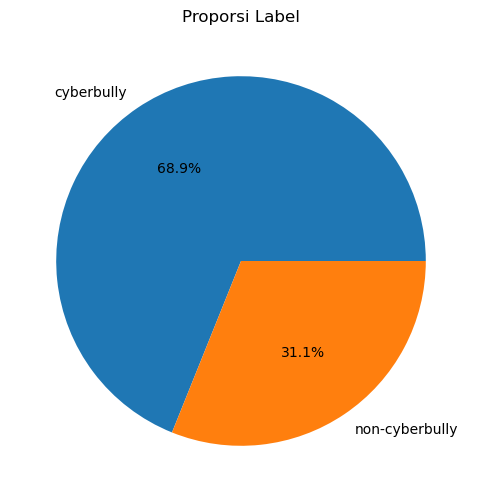

In [22]:
# Pie Chart Distribusi Label

df_processed['Label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)
plt.title('Proporsi Label')
plt.ylabel('')
plt.show()

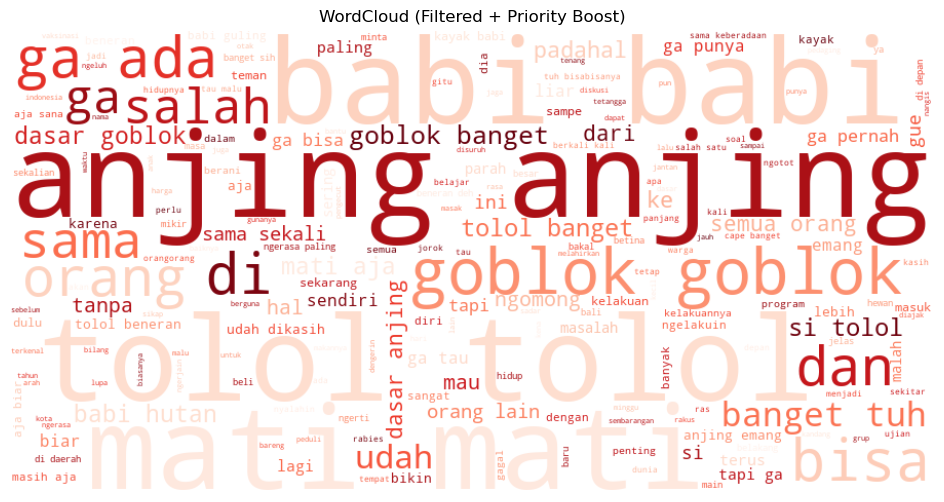

In [28]:
# Wordcloud

# kata yang diprioritaskan
priority_words = {
    "anjing": 50,
    "tolol": 50,
    "babi": 50,
    "mati": 50,
    "goblok": 50
}

# kata yang mau dihapus
stopwords_custom = {"lo", "yang", "itu"}

# ambil text
text = df_processed['Sentimen_clean'].astype(str).str.lower()

# cleaning stopwords
def clean_text(text):
    words = text.split()
    return [w for w in words if w not in stopwords_custom]

cleaned = text.apply(clean_text)

# gabungkan semua kata
boosted_text = []
for row in cleaned:
    boosted_text.extend(row)

# boost kata prioritas
for word, weight in priority_words.items():
    boosted_text += [word] * weight

final_text = " ".join(boosted_text)

# WordCloud
wc = WordCloud(
    width=900,
    height=450,
    background_color='white',
    colormap='Reds'
).generate(final_text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud (Filtered + Priority Boost)")
plt.show()

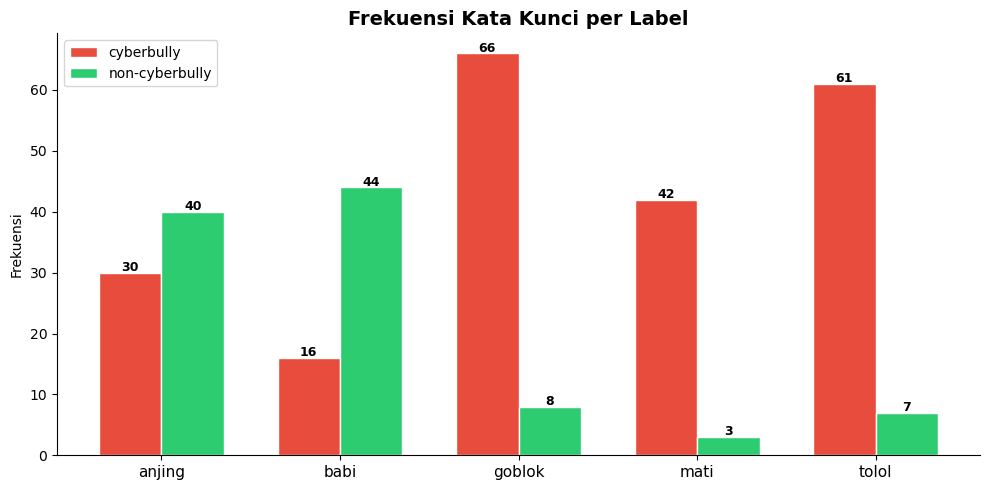

In [38]:
# Frekuensi Kata Kunci

kata_kunci = ['anjing', 'babi', 'goblok', 'mati', 'tolol']

def hitung_frekuensi(df, label):
    teks = ' '.join(df[df['Label'] == label]['Sentimen_clean'].astype(str))
    return [teks.split().count(k) for k in kata_kunci]

freq_bully    = hitung_frekuensi(df_processed, 'cyberbully')
freq_nonbully = hitung_frekuensi(df_processed, 'non-cyberbully')

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(kata_kunci))
w = 0.35
b1 = ax.bar(x - w/2, freq_bully,    w, label='cyberbully',     color='#E74C3C', edgecolor='white')
b2 = ax.bar(x + w/2, freq_nonbully, w, label='non-cyberbully', color='#2ECC71', edgecolor='white')
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
            str(h), ha='center', fontsize=9, fontweight='bold')
ax.set_title('Frekuensi Kata Kunci per Label', fontsize=14, fontweight='bold')
ax.set_ylabel('Frekuensi')
ax.set_xticks(x); ax.set_xticklabels(kata_kunci, fontsize=11)
ax.legend(); ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz_2_frekuensi.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
X = df_processed['Sentimen_clean']
y = df_processed['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {len(X_train)} | X_test: {len(X_test)}")

X_train: 249 | X_test: 63


In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Ubah teks ke angka dengan TF-IDF
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

# Barulah fit model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

print("✅ Model berhasil dilatih!")

✅ Model berhasil dilatih!


=== Naive Bayes ===
Accuracy: 0.9047619047619048
                precision    recall  f1-score   support

    cyberbully       0.88      1.00      0.93        43
non-cyberbully       1.00      0.70      0.82        20

      accuracy                           0.90        63
     macro avg       0.94      0.85      0.88        63
  weighted avg       0.92      0.90      0.90        63



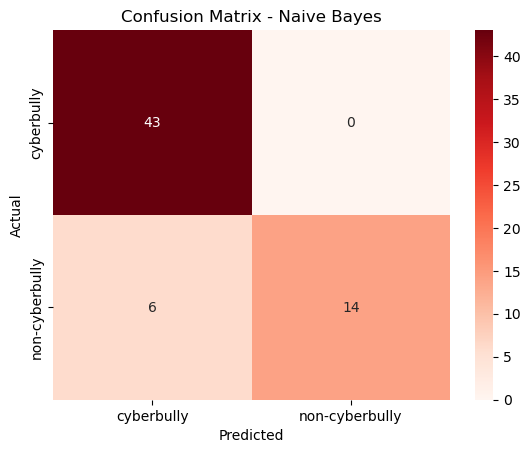

In [42]:
# Naive Bayes

y_pred_nb = nb_model.predict(X_test_tfidf)  # bukan X_test

print("=== Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Reds',
            xticklabels=['cyberbully', 'non-cyberbully'],
            yticklabels=['cyberbully', 'non-cyberbully'])
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

=== Logistic Regression ===
Accuracy: 0.9365079365079365
                precision    recall  f1-score   support

    cyberbully       0.91      1.00      0.96        43
non-cyberbully       1.00      0.80      0.89        20

      accuracy                           0.94        63
     macro avg       0.96      0.90      0.92        63
  weighted avg       0.94      0.94      0.93        63



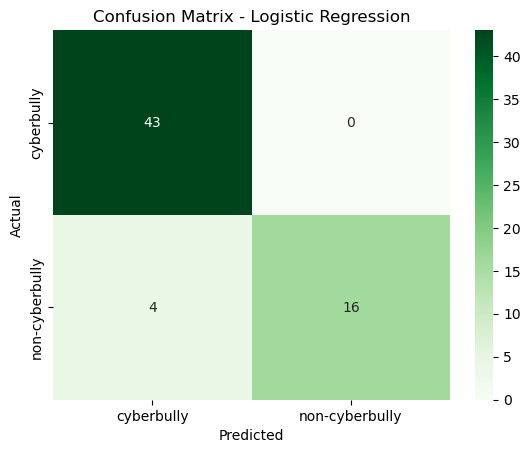

In [43]:
# Logistic Regression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)        # bukan X_train
y_pred_lr = lr_model.predict(X_test_tfidf)  # bukan X_test

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['cyberbully', 'non-cyberbully'],
            yticklabels=['cyberbully', 'non-cyberbully'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [44]:
# Perbandingan

print("=== Perbandingan Akurasi ===")
print(f"Naive Bayes        : {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Logistic Regression: {accuracy_score(y_test, y_pred_lr):.4f}")

=== Perbandingan Akurasi ===
Naive Bayes        : 0.9048
Logistic Regression: 0.9365
